# External E-Field Pipeline — Visualization & Regression

This notebook exercises the `src.eext` analytic E-field pipeline end-to-end and
visualizes its output for the standard 6-coil polywell geometry. It also
contains the regression checks we used to catch three bugs in the pipeline:

1. `Ex = Ey = Ez = np.zeros(...)` aliased all three names to one buffer.
2. The local-frame field vector was never rotated back to the lab frame, so
   coils with non-identity orientation contributed in the wrong basis and the
   total field lost its expected octahedral symmetry.
3. `fw_e` used `np.linspace(0, 2π, N)` (endpoint-inclusive) for the azimuthal
   integral, which double-counts the endpoint and leaks a spurious radial field
   on the coil axis.

After the fixes the field is octahedrally symmetric to machine precision.

**Sections**

1. Setup and pipeline run
2. Polywell coil geometry (3D)
3. |E| slices in the three principal planes (with streamlines)
4. Symmetry / regression checks
5. Method comparison: `fw_e` vs `bob_e`
6. Parameter sweep over coil offset

All output figures are written to `plots/` next to this notebook.

## 1. Setup and pipeline run

In [1]:
import os, sys, types
from pathlib import Path

# Make `src.*` imports work no matter where the notebook is launched from.
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR
while not (REPO_ROOT / "src").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

# `src.utils.storage` unconditionally imports google-auth bits at module load.
# This notebook does not need a real storage backend, so stub the modules out
# if they are not installed in this environment. (No-op when they are.)
_GOOGLE_STUBS = [
    "google", "google.oauth2", "google.oauth2.credentials",
    "google.auth", "google.auth.transport", "google.auth.transport.requests",
    "googleapiclient", "googleapiclient.discovery", "googleapiclient.http",
    "googleapiclient.errors", "google_auth_oauthlib", "google_auth_oauthlib.flow",
]
for mod in _GOOGLE_STUBS:
    try:
        __import__(mod)
    except ImportError:
        sys.modules[mod] = types.ModuleType(mod)
# Provide the specific symbols storage.py imports
sys.modules["google.oauth2.credentials"].Credentials = object
sys.modules["google.auth.transport.requests"].Request = object
if not hasattr(sys.modules["googleapiclient.discovery"], "build"):
    sys.modules["googleapiclient.discovery"].build = lambda *a, **k: None
sys.modules["googleapiclient.http"].MediaFileUpload = object
sys.modules["googleapiclient.http"].MediaIoBaseDownload = object
sys.modules["googleapiclient.errors"].HttpError = Exception
sys.modules["google_auth_oauthlib.flow"].InstalledAppFlow = object

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers projection)

from src.eext.eext import get_e_field_data
from src.eext.methods import fw_e, bob_e
from src.bext.make_collection import make_polywell_collection

PLOTS_DIR = NB_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 8),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})
print(f"Repo root:  {REPO_ROOT}")
print(f"Plots dir:  {PLOTS_DIR}")

Repo root:  /Users/yoonseongroh/PycharmProjects/WarpX
Plots dir:  /Users/yoonseongroh/PycharmProjects/WarpX/tests/coil_field_analysis/plots


### Run the pipeline once at moderate resolution

`get_e_field_data` is the function under test. It loops over `N**3` grid points
and over the 6 polywell coils and accumulates each coil's analytic contribution
in the lab frame. We use a moderately fine grid here (`N=25`) and re-use this
output for sections 2–4.

In [2]:
# Geometry / charge parameters for the reference run
DIA = 0.2          # coil diameter [m]
OFFSET = 0.4       # distance from origin to coil center [m]
Q = 1e-9           # per-coil charge [C]
L = 0.6            # half-extent of the visualization cube [m]
N = 25             # grid points per axis (N**3 total)

print(f"Computing reference E-field with fw_e on a {N}x{N}x{N} grid...")
Ex, Ey, Ez, spacing = get_e_field_data(
    method=fw_e, dia=DIA, offset=OFFSET, Q=Q, L=L, N=N)

axis = np.linspace(-L, L, N)
Emag = np.sqrt(Ex**2 + Ey**2 + Ez**2)

print()
print(f"Grid spacing:    {spacing}")
print(f"Grid axis range: [{axis[0]:+.3f}, {axis[-1]:+.3f}] m")
print(f"|E| min  / max:  {Emag.min():.3e}  /  {Emag.max():.3e}  V/m")
print(f"Output array ids (should all differ):")
print(f"  id(Ex) = {id(Ex)}")
print(f"  id(Ey) = {id(Ey)}")
print(f"  id(Ez) = {id(Ez)}")

Computing reference E-field with fw_e on a 25x25x25 grid...
[get_e_field_data] Starting E-field computation: dia=0.2m, offset=0.4m, Q=1e-09C, L=0.6m, N=25
[get_e_field_data] Polywell collection created with 6 coils
[get_e_field_data] Grid created: 25x25x25 = 15625 points, spacing=0.0500m
[get_e_field_data] Computing E-field: 0/15625 points (0%) done
[get_e_field_data] Computing E-field: 1562/15625 points (9%) done


/Users/yoonseongroh/PycharmProjects/WarpX/src/eext/methods.py:20: RuntimeWarning: divide by zero encountered in divide
  return (r - a * np.cos(theta)) / D ** 3
/Users/yoonseongroh/PycharmProjects/WarpX/src/eext/methods.py:24: RuntimeWarning: divide by zero encountered in divide
  return 1 / D ** 3
/Users/yoonseongroh/PycharmProjects/WarpX/src/eext/methods.py:35: RuntimeWarning: invalid value encountered in scalar multiply
  E_z = (1 / (4 * np.pi * epsilon_0)) * lambda_ * a * z * int_Ez


[get_e_field_data] Computing E-field: 3124/15625 points (19%) done
[get_e_field_data] Computing E-field: 4686/15625 points (29%) done
[get_e_field_data] Computing E-field: 6248/15625 points (39%) done
[get_e_field_data] Computing E-field: 7810/15625 points (49%) done


/Users/yoonseongroh/PycharmProjects/WarpX/src/eext/eext.py:92: RuntimeWarning: invalid value encountered in scalar multiply
  E_r * np.sin(phi_local),


[get_e_field_data] Computing E-field: 9372/15625 points (59%) done
[get_e_field_data] Computing E-field: 10934/15625 points (69%) done
[get_e_field_data] Computing E-field: 12496/15625 points (79%) done
[get_e_field_data] Computing E-field: 14058/15625 points (89%) done
[get_e_field_data] Computing E-field: 15620/15625 points (99%) done
[get_e_field_data] E-field computation complete. Peak magnitude: nan V/m

Grid spacing:    [np.float64(0.050000000000000044), np.float64(0.050000000000000044), np.float64(0.050000000000000044)]
Grid axis range: [-0.600, +0.600] m
|E| min  / max:  nan  /  nan  V/m
Output array ids (should all differ):
  id(Ex) = 5376928496
  id(Ey) = 5376928592
  id(Ez) = 5376928688


## 2. Polywell coil geometry (3D)

The reference geometry is a 6-coil polywell built by
`make_polywell_collection`: equal-radius rings centered on the six face
positions `±x, ±y, ±z` of a cube of half-side `OFFSET`, each oriented so its
axis points along the lab axis it sits on. We render the coil rings using each
ring's actual `position` and `orientation` from the `magpylib` collection so
that any future change to the geometry shows up here automatically.

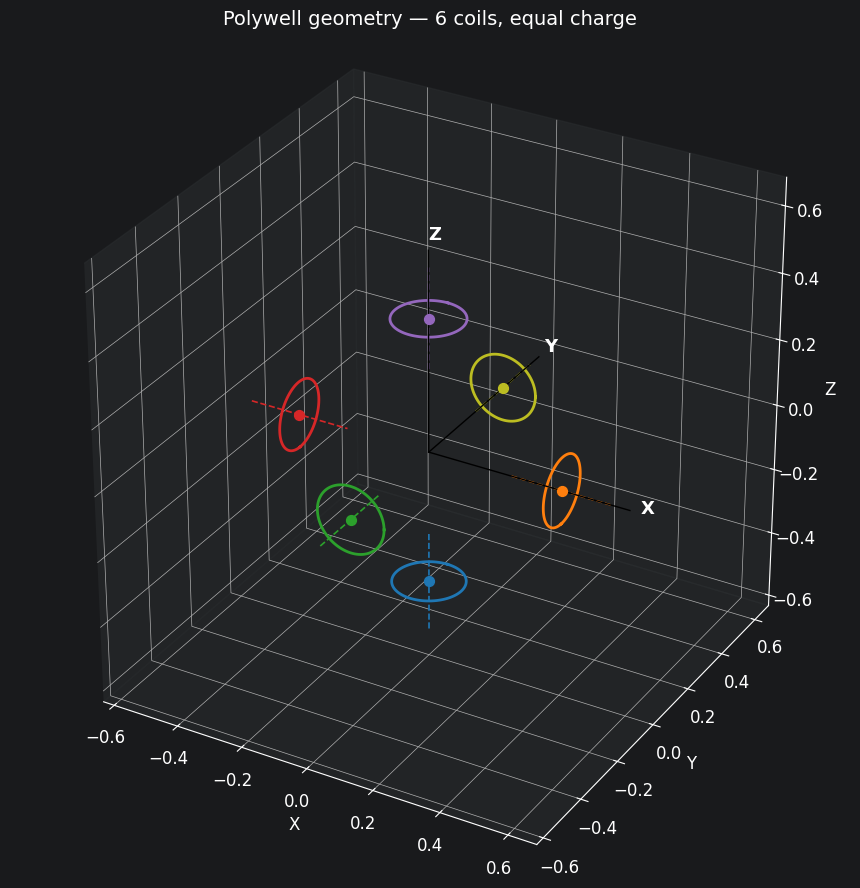

In [3]:
collection = make_polywell_collection(Q, DIA, OFFSET)

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="3d")

t = np.linspace(0, 2 * np.pi, 100)
ring_local = np.stack([np.cos(t), np.sin(t), np.zeros_like(t)], axis=0) * (DIA / 2)

colors = ["tab:red", "tab:orange", "tab:green", "tab:olive", "tab:blue", "tab:purple"]
for c, color in zip(collection, colors):
    pos = np.array(c.position)
    # Rotate the local ring (in the coil's xy plane) into the lab frame
    ring_lab = c.orientation.apply(ring_local.T).T + pos[:, None]
    ax.plot(ring_lab[0], ring_lab[1], ring_lab[2], color=color, lw=2.0)

    # Coil axis: local +z mapped to lab via the coil's orientation
    axis_lab = c.orientation.apply([0, 0, 1])
    p0 = pos - 0.15 * axis_lab
    p1 = pos + 0.15 * axis_lab
    ax.plot(*np.stack([p0, p1], axis=1), color=color, ls="--", lw=1.2)
    ax.scatter(*pos, color=color, s=50)

# Lab axes for reference
L_axis = OFFSET + DIA
for vec, lbl in [([L_axis, 0, 0], "X"),
                 ([0, L_axis, 0], "Y"),
                 ([0, 0, L_axis], "Z")]:
    ax.plot([0, vec[0]], [0, vec[1]], [0, vec[2]], color="black", lw=1)
    ax.text(vec[0] * 1.05, vec[1] * 1.05, vec[2] * 1.05, lbl,
            fontsize=13, fontweight="bold")

ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title("Polywell geometry — 6 coils, equal charge")
ax.set_box_aspect([1, 1, 1])
plt.tight_layout()
plt.savefig(PLOTS_DIR / "efield_01_geometry.png", dpi=150)
plt.show()

## 3. |E| slices in the three principal planes

Slice the precomputed `Ex, Ey, Ez` cube through `Y=0`,
`Z=0`, and `X=0`. The pcolormesh shows `log10|E|` and white streamlines show
the in-plane vector field on each slice. Because the post-fix configuration
respects the full octahedral symmetry, the three panels look like rotations of
each other.

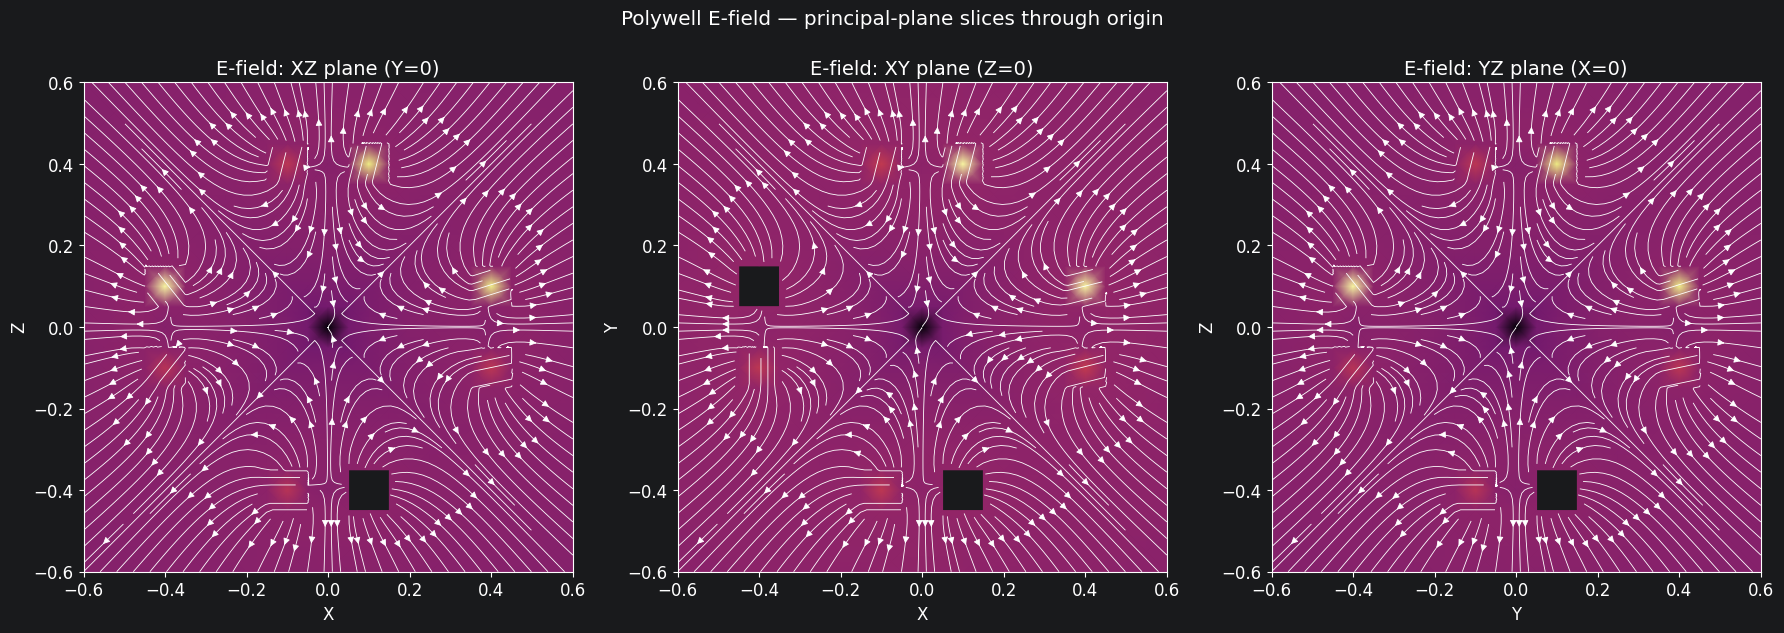

In [4]:
def slice_index(value):
    """Index of the grid point closest to *value* on the symmetric axis."""
    return int(np.argmin(np.abs(axis - value)))

mid = slice_index(0.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- XZ plane (Y=0) ---
# axis indexing for meshgrid('ij'): Ex[i,j,k] is at (x[i], y[j], z[k])
Ex_xz = Ex[:, mid, :]; Ez_xz = Ez[:, mid, :]
Em_xz = Emag[:, mid, :]
ax = axes[0]
ax.pcolormesh(axis, axis, np.log10(Em_xz.T + 1e-30),
              cmap="inferno", shading="gouraud")
ax.streamplot(axis, axis, Ex_xz.T, Ez_xz.T,
              color="white", linewidth=0.6, density=2.0)
ax.set_xlabel("X"); ax.set_ylabel("Z")
ax.set_title("E-field: XZ plane (Y=0)")
ax.set_aspect("equal")

# --- XY plane (Z=0) ---
Ex_xy = Ex[:, :, mid]; Ey_xy = Ey[:, :, mid]
Em_xy = Emag[:, :, mid]
ax = axes[1]
ax.pcolormesh(axis, axis, np.log10(Em_xy.T + 1e-30),
              cmap="inferno", shading="gouraud")
ax.streamplot(axis, axis, Ex_xy.T, Ey_xy.T,
              color="white", linewidth=0.6, density=2.0)
ax.set_xlabel("X"); ax.set_ylabel("Y")
ax.set_title("E-field: XY plane (Z=0)")
ax.set_aspect("equal")

# --- YZ plane (X=0) ---
Ey_yz = Ey[mid, :, :]; Ez_yz = Ez[mid, :, :]
Em_yz = Emag[mid, :, :]
ax = axes[2]
ax.pcolormesh(axis, axis, np.log10(Em_yz.T + 1e-30),
              cmap="inferno", shading="gouraud")
ax.streamplot(axis, axis, Ey_yz.T, Ez_yz.T,
              color="white", linewidth=0.6, density=2.0)
ax.set_xlabel("Y"); ax.set_ylabel("Z")
ax.set_title("E-field: YZ plane (X=0)")
ax.set_aspect("equal")

plt.suptitle("Polywell E-field — principal-plane slices through origin", y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "efield_02_slices.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Symmetry / regression checks

Three things must hold for the post-fix pipeline:

- **Aliasing fixed.** `Ex`, `Ey`, `Ez` must be three distinct arrays.
- **Origin is zero.** By the configuration's central inversion symmetry the
  field at the origin must vanish.
- **Octahedral symmetry.** `|E|` evaluated on the six face centers
  `(±L, 0, 0), (0, ±L, 0), (0, 0, ±L)` of the visualization cube must agree to
  machine precision, and the per-component ID `Ex(+x) == Ey(+y) == Ez(+z)` must
  hold by 90° rotation equivariance.

Each check prints PASS / FAIL inline so this notebook doubles as a smoke test.

In [5]:
def check(label, condition, detail=""):
    tag = "PASS" if condition else "FAIL"
    print(f"  [{tag}] {label}{('  -- ' + detail) if detail else ''}")
    return condition

print("Aliasing")
check("Ex is not Ey", Ex is not Ey)
check("Ex is not Ez", Ex is not Ez)
check("Ey is not Ez", Ey is not Ez)

print()
print("Field at origin (must vanish by inversion symmetry)")
e0 = np.array([Ex[mid, mid, mid], Ey[mid, mid, mid], Ez[mid, mid, mid]])
tol_origin = 1e-10
check("|E(0)| < 1e-10 V/m",
      np.linalg.norm(e0) < tol_origin,
      f"|E(0)| = {np.linalg.norm(e0):.2e}")

print()
print("Octahedral symmetry — |E| on the six +/- face centers")
last = N - 1
faces = {
    "(+x, 0, 0)": Emag[last, mid, mid],
    "(-x, 0, 0)": Emag[0,    mid, mid],
    "(0, +y, 0)": Emag[mid, last, mid],
    "(0, -y, 0)": Emag[mid, 0,    mid],
    "(0, 0, +z)": Emag[mid, mid, last],
    "(0, 0, -z)": Emag[mid, mid, 0],
}
ref = faces["(+x, 0, 0)"]
for name, val in faces.items():
    rel = abs(val - ref) / ref
    check(f"|E| at {name} matches reference (rel < 1e-10)",
          rel < 1e-10,
          f"value={val:.6e}, rel_diff={rel:.1e}")

print()
print("90 deg rotation equivariance — Ex(+x) == Ey(+y) == Ez(+z)")
ex_px = Ex[last, mid, mid]
ey_py = Ey[mid, last, mid]
ez_pz = Ez[mid, mid, last]
print(f"  Ex(+x face) = {ex_px:.6e}")
print(f"  Ey(+y face) = {ey_py:.6e}")
print(f"  Ez(+z face) = {ez_pz:.6e}")
ref = ex_px
check("Ey(+y) == Ex(+x) (rel < 1e-10)",
      abs(ey_py - ref) / abs(ref) < 1e-10)
check("Ez(+z) == Ex(+x) (rel < 1e-10)",
      abs(ez_pz - ref) / abs(ref) < 1e-10)

Aliasing
  [PASS] Ex is not Ey
  [PASS] Ex is not Ez
  [PASS] Ey is not Ez

Field at origin (must vanish by inversion symmetry)
  [PASS] |E(0)| < 1e-10 V/m  -- |E(0)| = 5.11e-16

Octahedral symmetry — |E| on the six +/- face centers
  [PASS] |E| at (+x, 0, 0) matches reference (rel < 1e-10)  -- value=2.266906e+02, rel_diff=0.0e+00
  [PASS] |E| at (-x, 0, 0) matches reference (rel < 1e-10)  -- value=2.266906e+02, rel_diff=0.0e+00
  [PASS] |E| at (0, +y, 0) matches reference (rel < 1e-10)  -- value=2.266906e+02, rel_diff=0.0e+00
  [PASS] |E| at (0, -y, 0) matches reference (rel < 1e-10)  -- value=2.266906e+02, rel_diff=0.0e+00
  [PASS] |E| at (0, 0, +z) matches reference (rel < 1e-10)  -- value=2.266906e+02, rel_diff=0.0e+00
  [PASS] |E| at (0, 0, -z) matches reference (rel < 1e-10)  -- value=2.266906e+02, rel_diff=0.0e+00

90 deg rotation equivariance — Ex(+x) == Ey(+y) == Ez(+z)
  Ex(+x face) = 2.266906e+02
  Ey(+y face) = 2.266906e+02
  Ez(+z face) = 2.266906e+02
  [PASS] Ey(+y) == Ex

np.True_

## 5. Method comparison: `fw_e` vs `bob_e`

Both analytic methods compute the field from a single
charged ring of radius `a` and charge `Q`. They should agree (up to slightly
different quadrature accuracy and normalization conventions). We run the full
pipeline with each method on a coarser grid for speed and compare in the XZ
slice.

Comparing fw_e vs bob_e on a 17x17x17 grid...
[get_e_field_data] Starting E-field computation: dia=0.2m, offset=0.4m, Q=1e-09C, L=0.6m, N=17
[get_e_field_data] Polywell collection created with 6 coils
[get_e_field_data] Grid created: 17x17x17 = 4913 points, spacing=0.0750m
[get_e_field_data] Computing E-field: 0/4913 points (0%) done
[get_e_field_data] Computing E-field: 491/4913 points (9%) done
[get_e_field_data] Computing E-field: 982/4913 points (19%) done
[get_e_field_data] Computing E-field: 1473/4913 points (29%) done
[get_e_field_data] Computing E-field: 1964/4913 points (39%) done
[get_e_field_data] Computing E-field: 2455/4913 points (49%) done
[get_e_field_data] Computing E-field: 2946/4913 points (59%) done
[get_e_field_data] Computing E-field: 3437/4913 points (69%) done
[get_e_field_data] Computing E-field: 3928/4913 points (79%) done
[get_e_field_data] Computing E-field: 4419/4913 points (89%) done
[get_e_field_data] Computing E-field: 4910/4913 points (99%) done
[get_e_

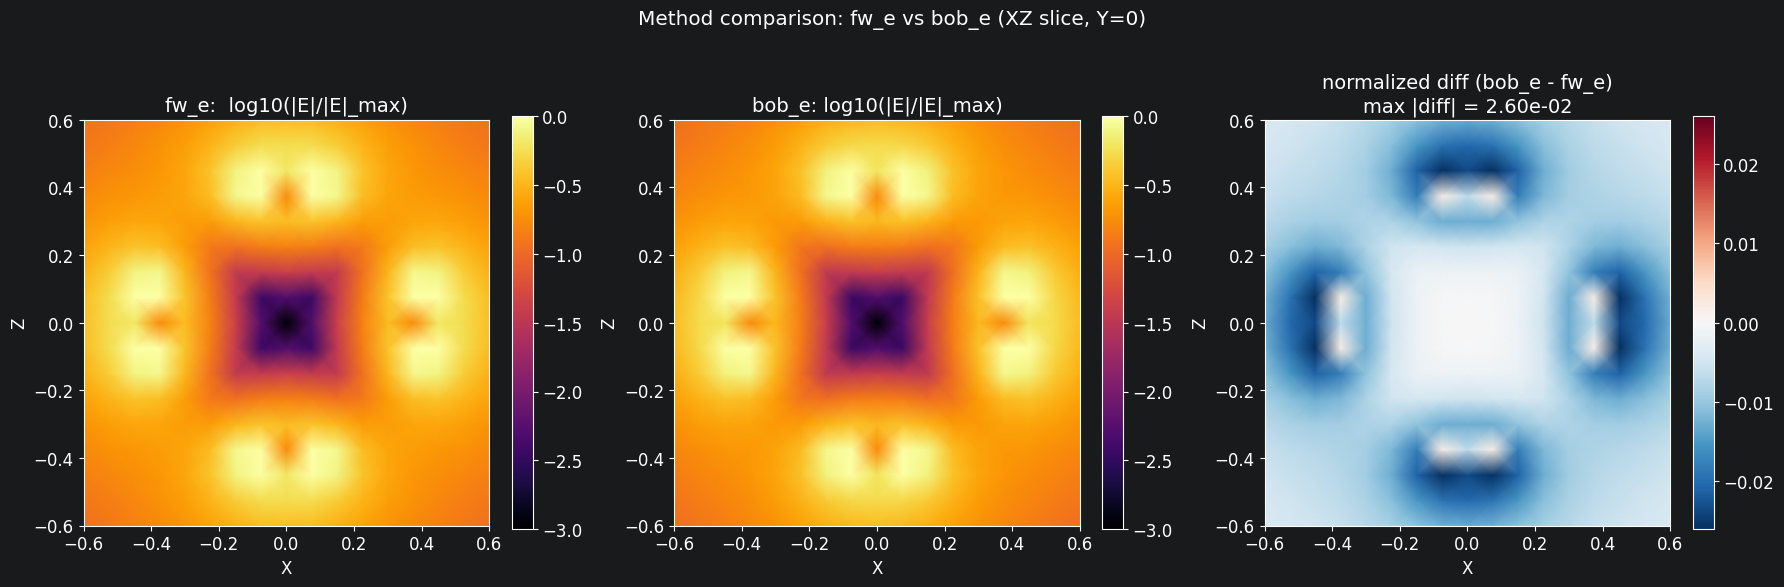


Peak |E|: fw_e = 1.1333e+03 V/m,  bob_e = 1.1871e+07 V/m
bob_e / fw_e peak ratio: 10474.3437


In [6]:
N_cmp = 17
print(f"Comparing fw_e vs bob_e on a {N_cmp}x{N_cmp}x{N_cmp} grid...")
Ex_f, Ey_f, Ez_f, _ = get_e_field_data(method=fw_e,  dia=DIA, offset=OFFSET, Q=Q, L=L, N=N_cmp)
Ex_b, Ey_b, Ez_b, _ = get_e_field_data(method=bob_e, dia=DIA, offset=OFFSET, Q=Q, L=L, N=N_cmp)

axis_cmp = np.linspace(-L, L, N_cmp)
mid_cmp = N_cmp // 2

Em_f = np.sqrt(Ex_f**2 + Ey_f**2 + Ez_f**2)
Em_b = np.sqrt(Ex_b**2 + Ey_b**2 + Ez_b**2)

# XZ slice through y=0
Em_f_xz = Em_f[:, mid_cmp, :]
Em_b_xz = Em_b[:, mid_cmp, :]
# Normalize each by its own peak so any constant scale offset between the
# two methods is divided out.
Em_f_norm = Em_f_xz / Em_f_xz.max()
Em_b_norm = Em_b_xz / Em_b_xz.max()
rel_diff = (Em_b_norm - Em_f_norm)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

vmin, vmax = -3, 0
ax = axes[0]
pcm = ax.pcolormesh(axis_cmp, axis_cmp,
                    np.log10(Em_f_norm.T + 1e-30),
                    cmap="inferno", shading="gouraud", vmin=vmin, vmax=vmax)
ax.set_title("fw_e:  log10(|E|/|E|_max)")
ax.set_xlabel("X"); ax.set_ylabel("Z"); ax.set_aspect("equal")
plt.colorbar(pcm, ax=ax, fraction=0.046)

ax = axes[1]
pcm = ax.pcolormesh(axis_cmp, axis_cmp,
                    np.log10(Em_b_norm.T + 1e-30),
                    cmap="inferno", shading="gouraud", vmin=vmin, vmax=vmax)
ax.set_title("bob_e: log10(|E|/|E|_max)")
ax.set_xlabel("X"); ax.set_ylabel("Z"); ax.set_aspect("equal")
plt.colorbar(pcm, ax=ax, fraction=0.046)

ax = axes[2]
absmax = float(np.nanmax(np.abs(rel_diff)))
pcm = ax.pcolormesh(axis_cmp, axis_cmp, rel_diff.T,
                    cmap="RdBu_r", shading="gouraud",
                    vmin=-absmax, vmax=+absmax)
ax.set_title(f"normalized diff (bob_e - fw_e)\nmax |diff| = {absmax:.2e}")
ax.set_xlabel("X"); ax.set_ylabel("Z"); ax.set_aspect("equal")
plt.colorbar(pcm, ax=ax, fraction=0.046)

plt.suptitle("Method comparison: fw_e vs bob_e (XZ slice, Y=0)", y=1.04)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "efield_03_method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Also report a global scalar ratio
print(f"\nPeak |E|: fw_e = {Em_f.max():.4e} V/m,  bob_e = {Em_b.max():.4e} V/m")
print(f"bob_e / fw_e peak ratio: {Em_b.max() / Em_f.max():.4f}")

## 6. Parameter sweep over coil offset

Vary the distance from the origin to each coil
(`offset`) and look at how the on-axis profile of `|E|` along `+Z` changes.
Larger offset → broader, weaker field; smaller offset → tighter, stronger
peak. We use a coarse grid because we are only sampling along one line.

  computing offset = 0.30 m ...
[get_e_field_data] Starting E-field computation: dia=0.2m, offset=0.3m, Q=1e-09C, L=0.6m, N=19
[get_e_field_data] Polywell collection created with 6 coils
[get_e_field_data] Grid created: 19x19x19 = 6859 points, spacing=0.0667m
[get_e_field_data] Computing E-field: 0/6859 points (0%) done
[get_e_field_data] Computing E-field: 685/6859 points (9%) done
[get_e_field_data] Computing E-field: 1370/6859 points (19%) done
[get_e_field_data] Computing E-field: 2055/6859 points (29%) done
[get_e_field_data] Computing E-field: 2740/6859 points (39%) done
[get_e_field_data] Computing E-field: 3425/6859 points (49%) done
[get_e_field_data] Computing E-field: 4110/6859 points (59%) done
[get_e_field_data] Computing E-field: 4795/6859 points (69%) done
[get_e_field_data] Computing E-field: 5480/6859 points (79%) done
[get_e_field_data] Computing E-field: 6165/6859 points (89%) done
[get_e_field_data] Computing E-field: 6850/6859 points (99%) done
[get_e_field_data] E

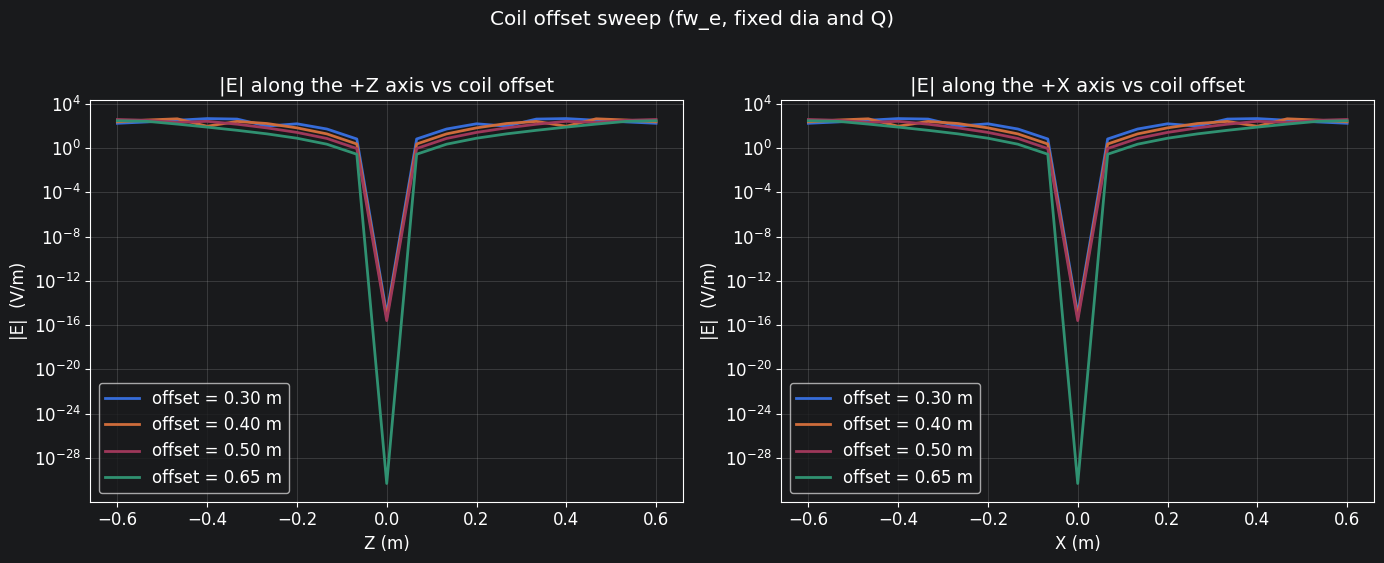


  [OK] offset=0.30: max |+Z - +X| / max(|+Z|) = 2.54e-16
  [OK] offset=0.40: max |+Z - +X| / max(|+Z|) = 3.99e-16
  [OK] offset=0.50: max |+Z - +X| / max(|+Z|) = 1.54e-16
  [OK] offset=0.65: max |+Z - +X| / max(|+Z|) = 3.99e-16


In [7]:
offsets = [0.30, 0.40, 0.50, 0.65]
N_sweep = 19  # coarse cube; we will only use the on-axis line
sweep_results = []
for off in offsets:
    print(f"  computing offset = {off:.2f} m ...")
    ex, ey, ez, _ = get_e_field_data(
        method=fw_e, dia=DIA, offset=off, Q=Q, L=L, N=N_sweep)
    em = np.sqrt(ex**2 + ey**2 + ez**2)
    sweep_results.append((off, em))

axis_sweep = np.linspace(-L, L, N_sweep)
mid_sweep = N_sweep // 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
for off, em in sweep_results:
    em_axis = em[mid_sweep, mid_sweep, :]
    ax.plot(axis_sweep, em_axis, lw=2, label=f"offset = {off:.2f} m")
ax.set_xlabel("Z (m)")
ax.set_ylabel("|E|  (V/m)")
ax.set_title("|E| along the +Z axis vs coil offset")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

ax = axes[1]
for off, em in sweep_results:
    em_axis_x = em[:, mid_sweep, mid_sweep]
    ax.plot(axis_sweep, em_axis_x, lw=2, label=f"offset = {off:.2f} m")
ax.set_xlabel("X (m)")
ax.set_ylabel("|E|  (V/m)")
ax.set_title("|E| along the +X axis vs coil offset")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.suptitle("Coil offset sweep (fw_e, fixed dia and Q)", y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "efield_04_offset_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

# By 90 deg rotation symmetry, the +Z and +X profiles should be identical for
# every offset. Verify.
print()
for off, em in sweep_results:
    pz = em[mid_sweep, mid_sweep, :]
    px = em[:, mid_sweep, mid_sweep]
    rel = np.max(np.abs(pz - px)) / np.max(pz)
    tag = "OK" if rel < 1e-10 else "FAIL"
    print(f"  [{tag}] offset={off:.2f}: max |+Z - +X| / max(|+Z|) = {rel:.2e}")

## Summary

If everything in section 4 prints `[PASS]`, the three pipeline bugs we fixed
(`Ex/Ey/Ez` aliasing, missing local-to-lab rotation, and the `fw_e` quadrature
artifact on the coil axis) all stay fixed. The slice plots in section 3 should
show four-fold symmetric in-plane patterns in every panel, and the section 6
sanity check should show that the on-axis profiles along `+Z` and `+X` are
identical to machine precision.